In [5]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("data/gold_match.csv")

Test season: 2025/2026
                 Model         MAE
  Model: Random Forest  898.573846
Baseline: Same Fixture 1410.076923
  Baseline: Season Avg 1416.022189
Baseline: Opponent Avg 1501.785897


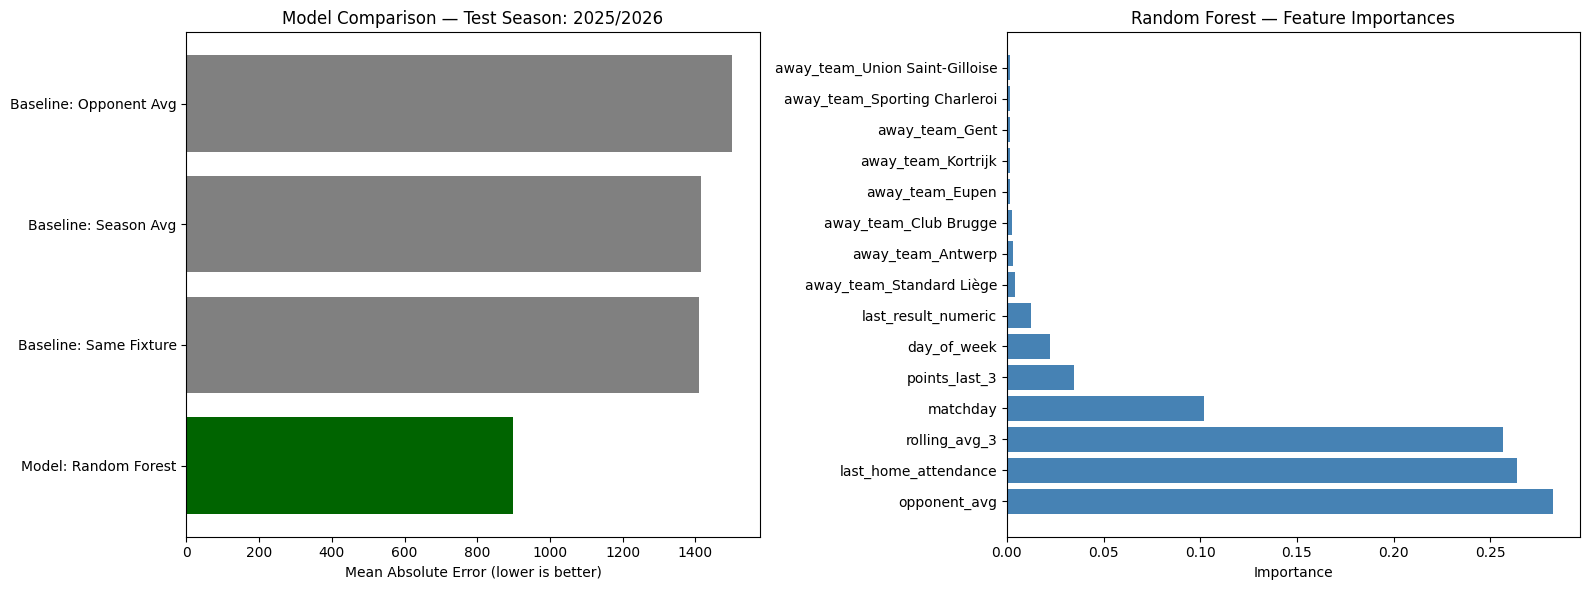

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["day_of_week"] = df["match_date"].dt.dayofweek
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
test_season = seasons[-1]
print(f"Test season: {test_season}")

train = df[df["season"] != test_season].copy()
test  = df[df["season"] == test_season].copy()

last_known_attendance = train["tickets_scanned"].iloc[-1]
last_known_rolling    = train["tickets_scanned"].tail(3).mean()
test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

features = ["away_team", "matchday", "day_of_week", "competition_name", "last_result_numeric", "points_last_3", "opponent_avg", "last_home_attendance", "rolling_avg_3"]

X_train = pd.get_dummies(train[features], columns=["away_team", "competition_name"], drop_first=True)
X_test  = pd.get_dummies(test[features],  columns=["away_team", "competition_name"], drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train["tickets_scanned"]
y_test  = test["tickets_scanned"]

season_avg   = train["tickets_scanned"].mean()
opponent_avg = test["away_team"].map(opponent_avg_train).fillna(season_avg)
same_fixture = train.groupby("away_team")["tickets_scanned"].last()

mae_season   = mean_absolute_error(y_test, [season_avg] * len(y_test))
mae_opponent = mean_absolute_error(y_test, opponent_avg)
mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

results_clean = {
    "Baseline: Season Avg":   mae_season,
    "Baseline: Same Fixture": mae_fixture,
    "Baseline: Opponent Avg": mae_opponent,
    "Model: Random Forest":   mae_rf,
}

results_df = pd.DataFrame(results_clean.items(), columns=["Model", "MAE"]).sort_values("MAE")
print(results_df.to_string(index=False))

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

colors = ["darkgreen" if m == "Model: Random Forest" else "grey" for m in results_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df["Model"], results_df["MAE"], color=colors)
axes[0].set_xlabel("Mean Absolute Error (lower is better)")
axes[0].set_title(f"Model Comparison — Test Season: {test_season}")

axes[1].barh(importance_df["feature"], importance_df["importance"], color="steelblue")
axes[1].set_xlabel("Importance")
axes[1].set_title("Random Forest — Feature Importances")

plt.tight_layout()
plt.show()

                   Model         MAE
Model: RF (all features) 1070.951538
       Model: RF (tuned) 1104.856173
    Baseline: Season Avg 1306.675700
  Baseline: Opponent Avg 1335.090780
  Baseline: Same Fixture 2117.680851
                       feature  importance
10               tickets_trib1    0.366492
47               rolling_avg_3    0.134462
46        last_home_attendance    0.112694
50             opponent_avg_bl    0.077313
7             tickets_sold_b2b    0.074292
13               tickets_trib3    0.036855
40            pct_free_tickets    0.016360
0                     matchday    0.015656
6             tickets_sold_b2c    0.014702
49           fixture_last_year    0.012114
14               tickets_trib4    0.011987
11         tickets_trib2_thuis    0.011789
22      weather_sunshine_hours    0.009779
43              result_minus_2    0.008515
303    academic_year_2024/2025    0.008215
21   weather_windspeed_max_kmh    0.007440
8           tickets_sold_total    0.005192
16  

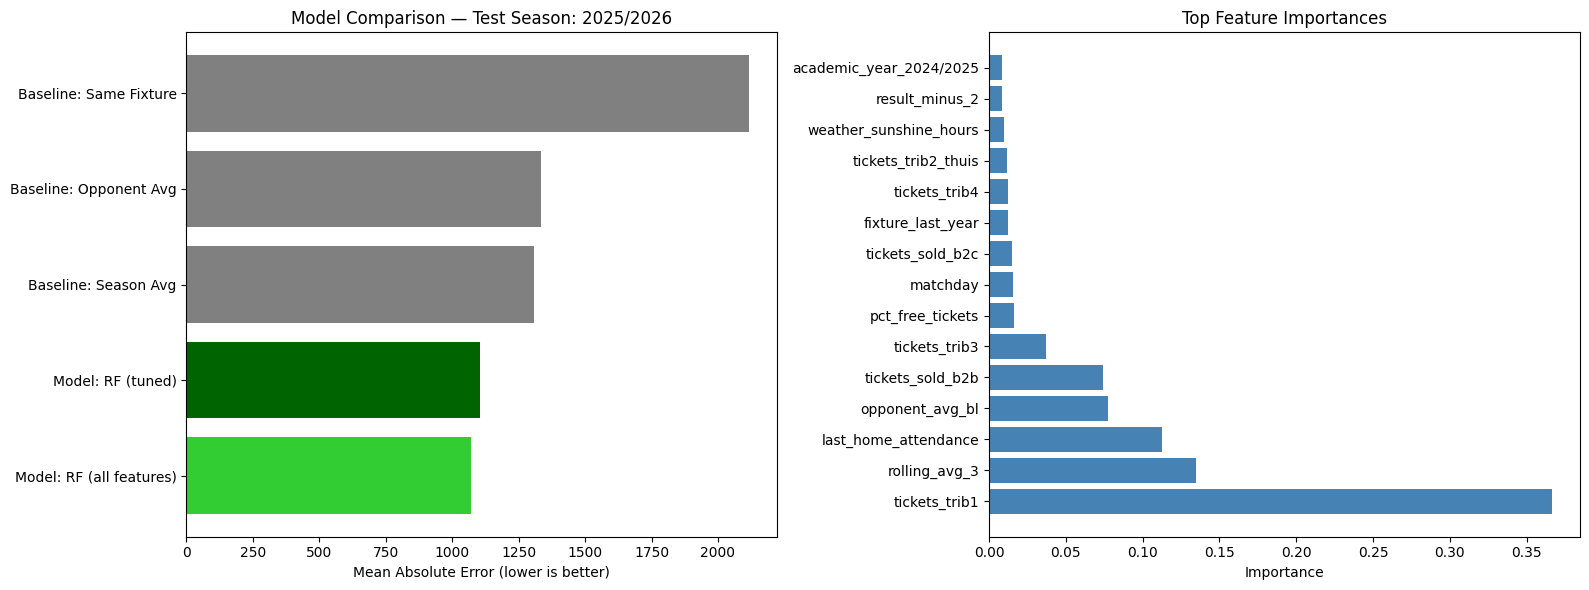

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    if value.startswith("D"): return 1
    if value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id": row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")

df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

df = df.sort_values(["away_team", "match_date"])
df["season_avg"] = df.groupby("season")["tickets_scanned"].transform("mean")
df["fixture_last_year"] = df.groupby("away_team")["tickets_scanned"].shift(1)
df["opponent_avg_bl"] = df.groupby("away_team")["tickets_scanned"].transform("mean")

df_baseline = df.dropna(subset=["fixture_last_year"])
mae_season = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["season_avg"])
mae_fixture = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["fixture_last_year"])
mae_opponent = mean_absolute_error(df_baseline["tickets_scanned"], df_baseline["opponent_avg_bl"])

seasons = sorted(df["season"].unique())
test_season = seasons[-1]

train = df[df["season"] != test_season].copy()
test  = df[df["season"] == test_season].copy()

last_known_attendance = train["tickets_scanned"].iloc[-1]
last_known_rolling = train["tickets_scanned"].tail(3).mean()

test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
test["rolling_avg_3"] = test["rolling_avg_3"].fillna(last_known_rolling)

opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
test["opponent_avg"] = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

drop_cols = ["match_id", "tickets_scanned", "match_date"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

df_model = pd.get_dummies(df_model, drop_first=True)

train_model = df_model[df["season"] != test_season]
test_model  = df_model[df["season"] == test_season]

X_train = train_model
X_test  = test_model
y_train = train["tickets_scanned"]
y_test  = test["tickets_scanned"]

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
mae_rf_base = mean_absolute_error(y_test, rf_base.predict(X_test))

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf_tuned = grid_search.best_estimator_
mae_rf_tuned = mean_absolute_error(y_test, rf_tuned.predict(X_test))

results_clean = {
    "Baseline: Season Avg": mae_season,
    "Baseline: Same Fixture": mae_fixture,
    "Baseline: Opponent Avg": mae_opponent,
    "Model: RF (all features)": mae_rf_base,
    "Model: RF (tuned)": mae_rf_tuned,
}

results_df = pd.DataFrame(results_clean.items(), columns=["Model", "MAE"]).sort_values("MAE")
print(results_df.to_string(index=False))

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_tuned.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

def bar_color(m):
    if m == "Model: RF (tuned)": return "darkgreen"
    if m == "Model: RF (all features)": return "limegreen"
    if "Baseline" in m: return "grey"
    return "steelblue"

colors = [bar_color(m) for m in results_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df["Model"], results_df["MAE"], color=colors)
axes[0].set_xlabel("Mean Absolute Error (lower is better)")
axes[0].set_title(f"Model Comparison — Test Season: {test_season}")

axes[1].barh(importance_df["feature"].head(15), importance_df["importance"].head(15), color="steelblue")
axes[1].set_xlabel("Importance")
axes[1].set_title("Top Feature Importances")

plt.tight_layout()
plt.show()

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1465 | Opponent Avg: 1853 | Season Avg: 1828 | Same Fixture: 2159 | n=13
2023/2024 — RF: 1801 | Opponent Avg: 2330 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1372 | Opponent Avg: 1317 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 929 | Opponent Avg: 1502 | Season Avg: 1416 | Same Fixture: 1410 | n=13


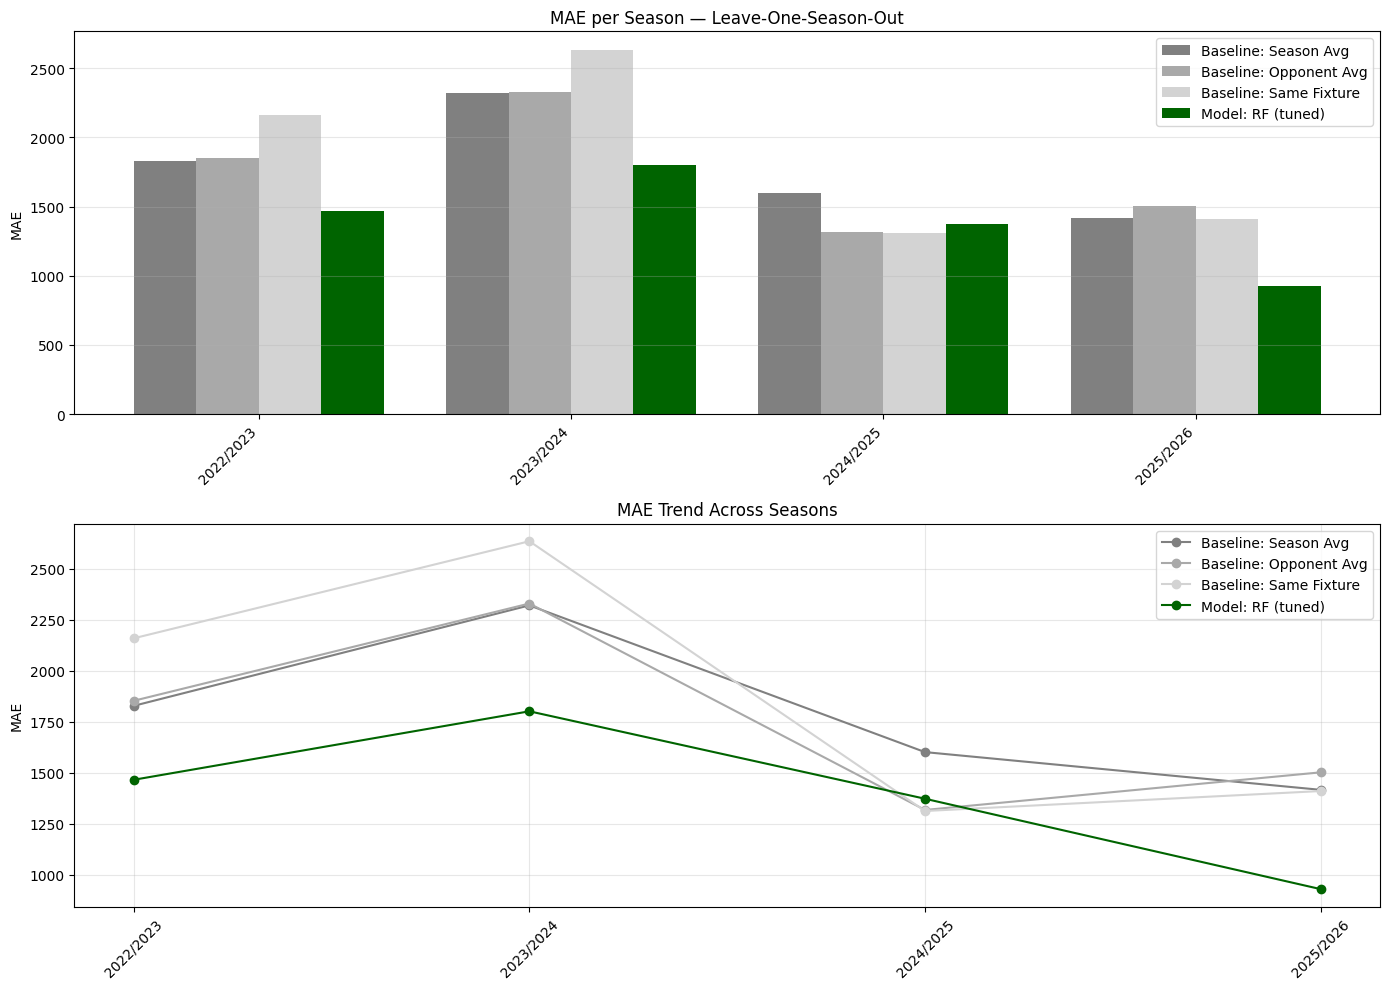

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(3).mean()
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

features = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday"]

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    if len(train) < 10 or len(test) < 5:
        continue

    last_known_attendance = train["tickets_scanned"].iloc[-1]
    last_known_rolling    = train["tickets_scanned"].tail(3).mean()
    test["last_home_attendance"] = test["last_home_attendance"].fillna(last_known_attendance)
    test["rolling_avg_3"]        = test["rolling_avg_3"].fillna(last_known_rolling)

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = train[features]
    X_test  = test[features]
    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":               test_season,
        "n_matches":            len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x = range(len(results_df))
width = 0.2

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Leave-One-Season-Out")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print(df[df["season"] == "2023/2024"].groupby("stage")["tickets_scanned"])
print(df[df["season"] == "2023/2024"].groupby("stage")["tickets_scanned"].agg(["mean", "count", "std"]).sort_values("mean", ascending=False).to_string())

                                         mean  count          std
stage                                                            
Regular Season                    9194.214286     14  1098.778495
Conference League Play-off Group  5361.400000      5   935.035454


Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1751 | Opponent Avg: 1886 | Season Avg: 1824 | Same Fixture: 1940 | n=16
2023/2024 — RF: 2264 | Opponent Avg: 2330 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1030 | Opponent Avg: 1317 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 652 | Opponent Avg: 1502 | Season Avg: 1416 | Same Fixture: 1410 | n=13


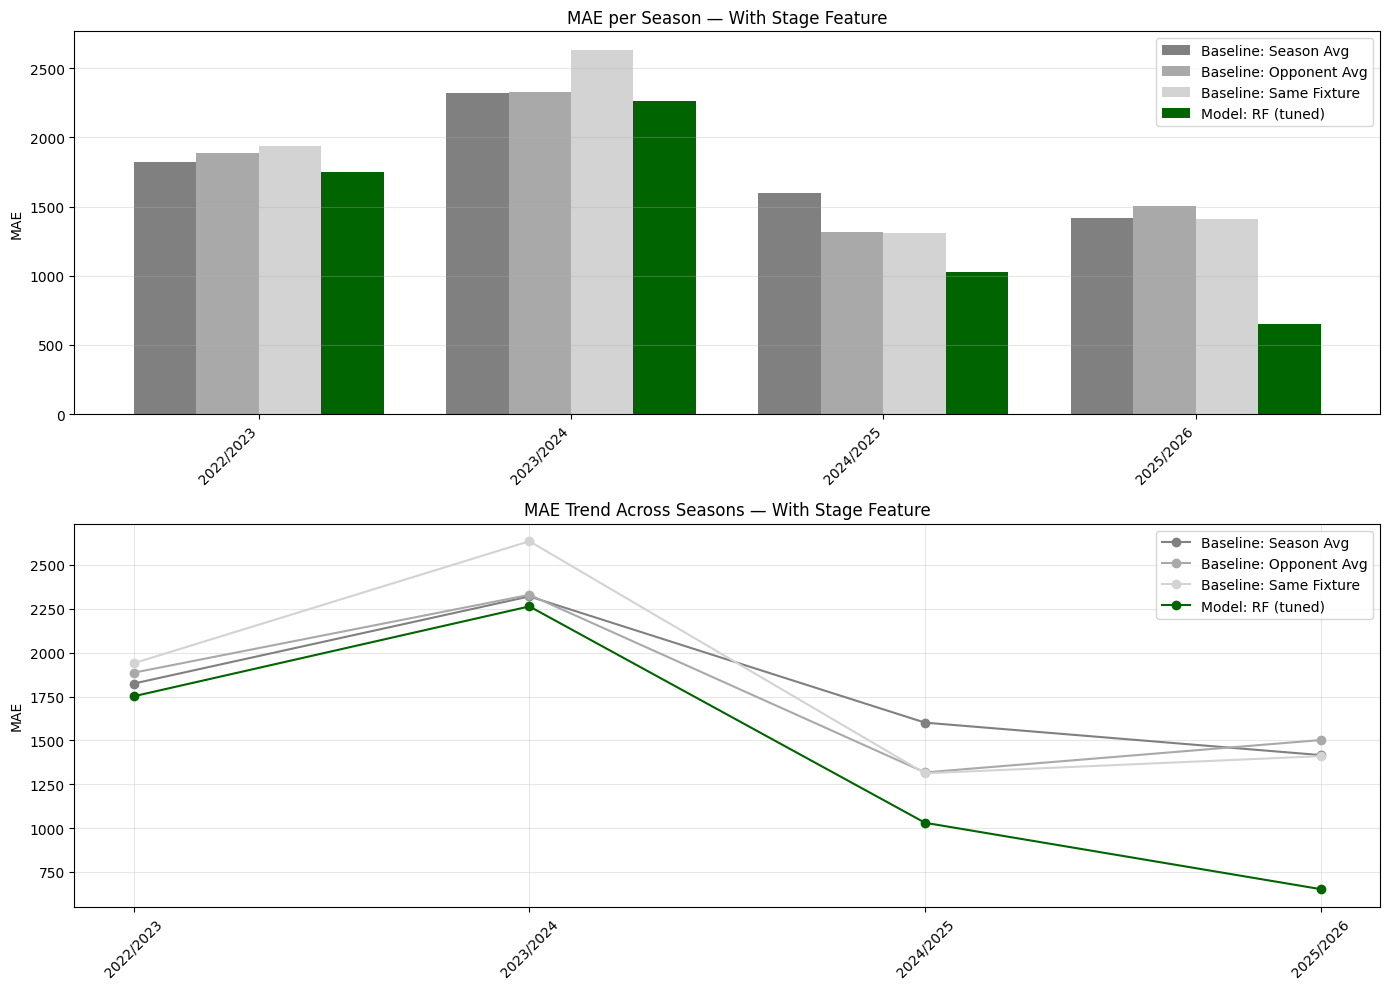

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage"]
numerical_features   = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday"]
features             = numerical_features + categorical_features

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy().sort_values("match_date")
    test  = df[df["season"] == test_season].copy().sort_values("match_date")

    if len(train) < 10 or len(test) < 5:
        continue

    train["last_home_attendance"] = train["tickets_scanned"].shift(1)
    train["rolling_avg_3"]        = train["tickets_scanned"].shift(1).rolling(3).mean()
    train = train.dropna(subset=["last_home_attendance", "rolling_avg_3"])

    test["last_home_attendance"] = train["tickets_scanned"].iloc[-1]
    test["rolling_avg_3"]        = train["tickets_scanned"].tail(3).mean()

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — With Stage Feature")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — With Stage Feature")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1750 | Opponent Avg: 1886 | Season Avg: 1824 | Same Fixture: 1940 | n=16
2023/2024 — RF: 2238 | Opponent Avg: 2330 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1009 | Opponent Avg: 1317 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 591 | Opponent Avg: 1502 | Season Avg: 1416 | Same Fixture: 1410 | n=13


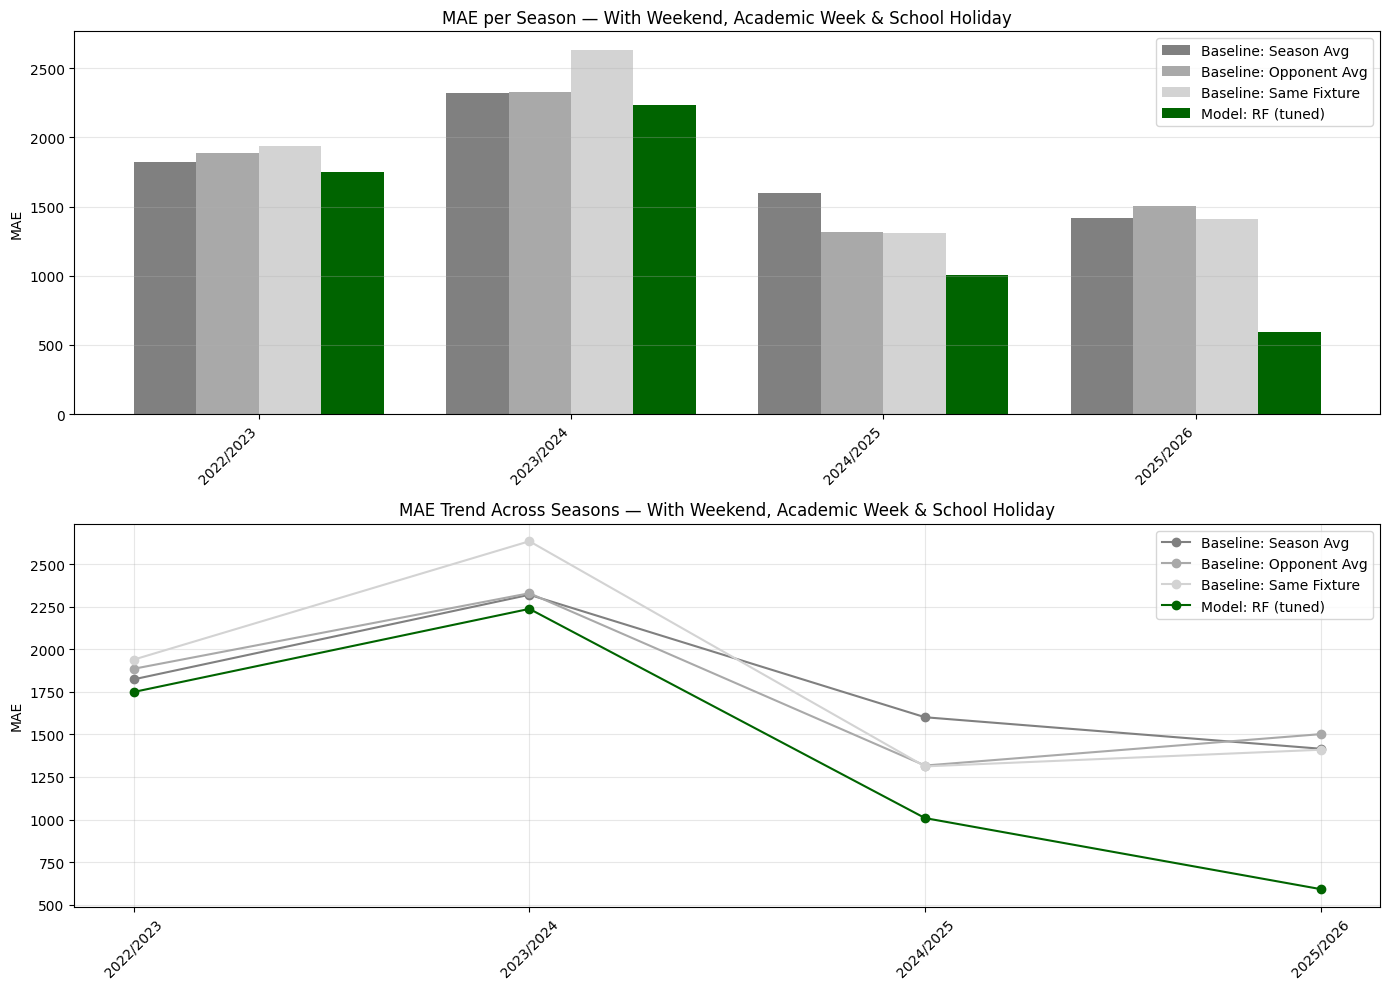

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df = df.sort_values(["away_team", "match_date"])

def last_n_results(df, opponent, current_idx, n=3):
    past = df[(df["away_team"] == opponent) & (df.index < current_idx)]
    return past["last_result_numeric"].tail(n).tolist()

records = []
for idx, row in df.iterrows():
    results = last_n_results(df, row["away_team"], idx)
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df = df.sort_values("match_date")
df["match_date"] = pd.to_datetime(df["match_date"])
df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage", "school_holiday_name"]
numerical_features   = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday", "is_weekend", "academic_week"]
features             = numerical_features + categorical_features

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy().sort_values("match_date")
    test  = df[df["season"] == test_season].copy().sort_values("match_date")

    if len(train) < 10 or len(test) < 5:
        continue

    train["last_home_attendance"] = train["tickets_scanned"].shift(1)
    train["rolling_avg_3"]        = train["tickets_scanned"].shift(1).rolling(3).mean()
    train = train.dropna(subset=["last_home_attendance", "rolling_avg_3"])

    test["last_home_attendance"] = train["tickets_scanned"].iloc[-1]
    test["rolling_avg_3"]        = train["tickets_scanned"].tail(3).mean()

    opponent_avg_train = train.groupby("away_team")["tickets_scanned"].mean()
    train["opponent_avg"] = train["away_team"].map(opponent_avg_train)
    test["opponent_avg"]  = test["away_team"].map(opponent_avg_train).fillna(train["tickets_scanned"].mean())

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["away_team"].map(opponent_avg_train).fillna(season_avg_val)
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — With Weekend, Academic Week & School Holiday")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — With Weekend, Academic Week & School Holiday")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1989 | Opponent Avg: 1824 | Season Avg: 1824 | Same Fixture: 1940 | n=16
2023/2024 — RF: 2285 | Opponent Avg: 2800 | Season Avg: 2321 | Same Fixture: 2635 | n=19
2024/2025 — RF: 1207 | Opponent Avg: 1507 | Season Avg: 1601 | Same Fixture: 1312 | n=20
2025/2026 — RF: 725 | Opponent Avg: 1387 | Season Avg: 1416 | Same Fixture: 1410 | n=13


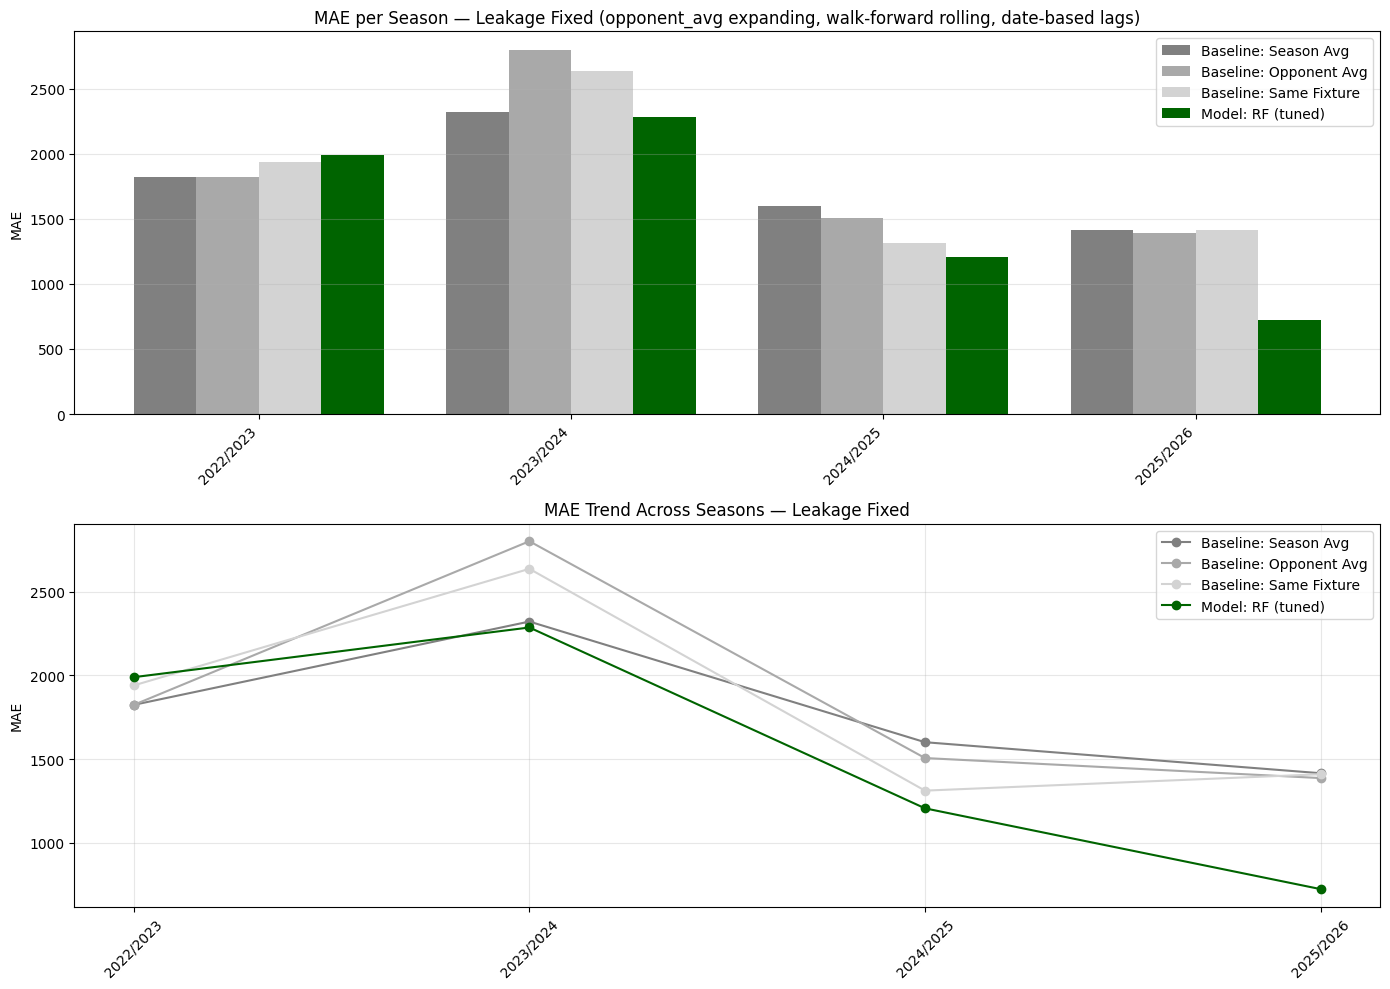

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

# ── FIX 1: Lag features filtered strictly by match_date, not by index ─────────
# Previously: df.index < current_idx relied on integer index order, which
# breaks if the DataFrame is ever re-sorted or re-indexed. Using match_date
# is robust and correctly excludes any test-season matches at the boundary.
records = []
for idx, row in df.iterrows():
    past = df[
        (df["away_team"] == row["away_team"]) &
        (df["match_date"] < row["match_date"])
    ]["last_result_numeric"]
    results = past.tail(3).tolist()
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = (
    df["result_minus_1"].fillna(0) +
    df["result_minus_2"].fillna(0) +
    df["result_minus_3"].fillna(0)
)

# ── FIX 2: opponent_avg computed as expanding mean over past matches only ──────
# Previously: opponent_avg_train = train.groupby(...).mean() computed a global
# average over ALL training rows including future ones. For match t, this
# leaked attendance figures from matches t+1, t+2, ... in the training set.
# Fix: shift(1).expanding().mean() within each opponent group — each row only
# sees the mean of matches strictly before it.
df = df.sort_values("match_date").reset_index(drop=True)
df["opponent_avg_expanding"] = (
    df.groupby("away_team")["tickets_scanned"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage", "school_holiday_name"]
numerical_features   = [
    "opponent_avg_expanding",   # replaces opponent_avg (leak-free)
    "last_home_attendance",
    "rolling_avg_3",
    "matchday",
    "is_weekend",
    "academic_week",
]
features = numerical_features + categorical_features

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy().sort_values("match_date")
    test  = df[df["season"] == test_season].copy().sort_values("match_date")

    if len(train) < 10 or len(test) < 5:
        continue

    # ── Lag-1 and rolling attendance features ────────────────────────────────
    # Training: use shift(1) so row t only sees t-1.
    train = train.copy()
    train["last_home_attendance"] = train["tickets_scanned"].shift(1)
    train["rolling_avg_3"]        = train["tickets_scanned"].shift(1).rolling(3).mean()
    train = train.dropna(subset=["last_home_attendance", "rolling_avg_3"])

    # ── FIX 3: Walk-forward update of rolling features on the test set ────────
    # Previously: both features were frozen at the last training value for every
    # test match — a static scalar applied to all 13+ test rows. This isn't
    # leakage, but it degrades accuracy as the season progresses. We now carry a
    # running buffer of the last 3 actual (or predicted) attendance values and
    # update it match-by-match. For real-time use, replace attendance_buffer
    # entries with actual scanned counts as they become available.
    attendance_buffer = list(train["tickets_scanned"].tail(3).values)

    last_home_attendances = []
    rolling_avg_3s        = []

    for _ in range(len(test)):
        last_home_attendances.append(attendance_buffer[-1])
        rolling_avg_3s.append(sum(attendance_buffer[-3:]) / min(3, len(attendance_buffer)))
        # Placeholder: append the rolling mean as a stand-in for the true value.
        # In production, replace this with the actual scanned count after each match.
        attendance_buffer.append(rolling_avg_3s[-1])

    test = test.copy()
    test["last_home_attendance"] = last_home_attendances
    test["rolling_avg_3"]        = rolling_avg_3s

    # opponent_avg for test: use the expanding value already computed on df
    # (which only saw matches before each date). Fill NaN opponents (new clubs)
    # with the training set global mean.
    global_train_mean = train["tickets_scanned"].mean()
    train["opponent_avg_expanding"] = train["opponent_avg_expanding"].fillna(global_train_mean)
    test["opponent_avg_expanding"]  = test["opponent_avg_expanding"].fillna(global_train_mean)

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    # Baselines
    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["opponent_avg_expanding"]           # leak-free expanding avg
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(
        n_estimators=200, max_depth=5,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(
        f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | "
        f"Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}"
    )

results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Leakage Fixed (opponent_avg expanding, walk-forward rolling, date-based lags)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — Leakage Fixed")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()